In [1]:
import pandas as pd
fruits = pd.read_csv('../data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feature Set과 Target Set를 Numpy Array로 변경

In [2]:
import numpy as np

### 연습

In [3]:
# numpy의 column stack과 row stack
# stack을 사용하면 매우 편하다
testA = np.array([1, 2, 3, 4])
testB = np.array([10, 20, 30, 40])

# 2개의 Array를 묶어서 컬럼기반의 Array로 만들기
combineA = [[i, j] for i, j in zip(testA, testB)]
print(np.array(combineA))



[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]


In [4]:
combineB = np.column_stack((testA, testB))
print(combineB)
print('-' * 50)
combineC = np.column_stack((testA, testB))
print(combineB)
print(combineC)
print('-' * 50)

[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------


In [5]:
### List Comprehension
test1 = []
# list(range(1, 10+1))
# for i in range(1, 10+1):
#     test1.append(i)
# test1

test1 = [i for i in range(1, 10+1) if i%2 == 0]
test1

[2, 4, 6, 8, 10]

In [6]:
fruits_data = np.column_stack((fruits.length, fruits.weight ))
print(fruits_data[:5])
print(fruits_data.shape)

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]
(49, 2)


In [7]:
fruits_target = np.array(fruits.name)
fruits_target[:5]

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data,
        fruits_target,
        random_state=42,
        stratify=fruits_target # target의 비율을 검토
    )


In [10]:
# kNN을 이용한 예측
from sklearn.neighbors import KNeighborsClassifier

In [11]:
# 모델 생성
kn = KNeighborsClassifier() # n_neighbors=5

# 학습시키기
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [12]:
print(kn.score(train_input, train_target))

1.0


In [13]:
print(kn.score(test_input, test_target))

1.0


---
### 수상한 과일

In [14]:
# length가 25cm이고 weight가 150g인 과일은?
kn.predict([[25, 150]])

array(['berry'], dtype=object)

### 시각화

In [15]:
import matplotlib.pyplot as plt

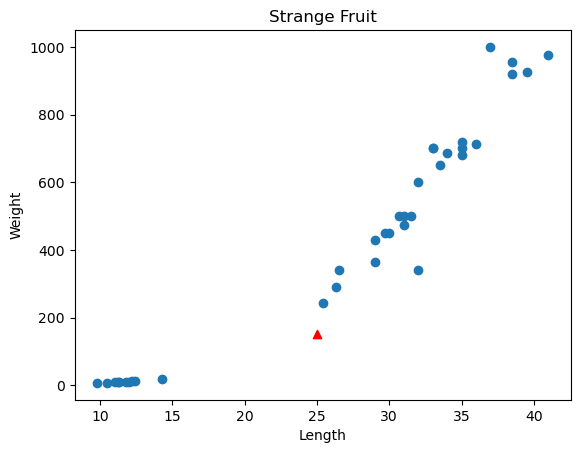

In [17]:
plt.scatter(
    train_input[:, 0],
    train_input[:, 1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Strange Fruit')

plt.show()

### 이웃을 출력해보자

In [19]:
distances, indexes = kn.kneighbors([[25, 150]])
print(indexes)

[[11 20 13 22 15]]


In [21]:
# 이웃 indexes에 해당하는 feature를 출력해보자
train_input[indexes]

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4],
        [ 12.2,  12.2],
        [ 26.3, 290. ]]])

In [22]:
# 이웃 indexes에 해당하는 target를 출력해보자
train_target[indexes]

array([['apple', 'berry', 'berry', 'berry', 'apple']], dtype=object)

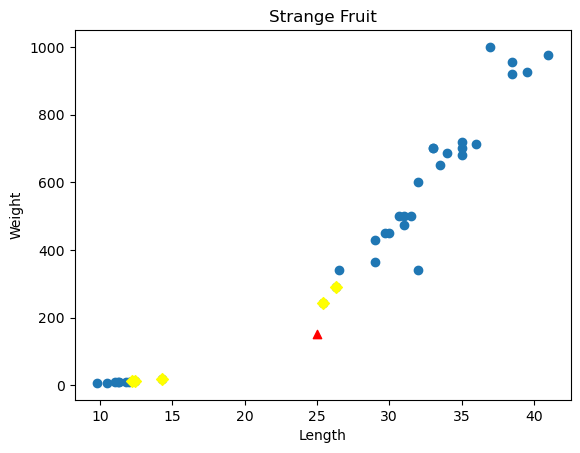

In [23]:
# 이웃의 위치를 출력
plt.scatter(
    train_input[:, 0],
    train_input[:, 1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D',
    c='yellow'
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Strange Fruit')

plt.show()

---
### 기준을 맞추자

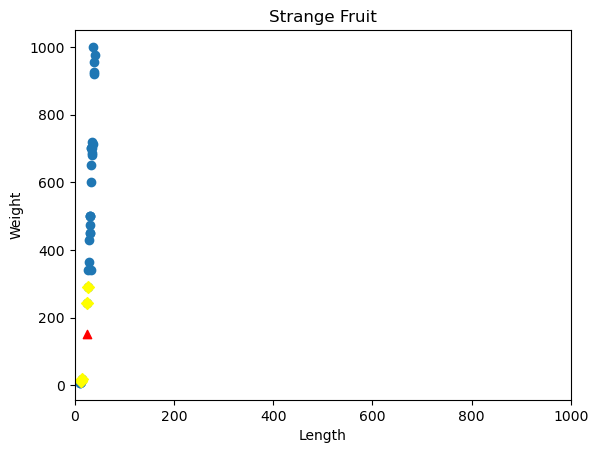

In [24]:
plt.scatter(
    train_input[:, 0],
    train_input[:, 1]
)

plt.scatter(
    25,
    150,
    marker="^",
    c='red'
)

plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D',
    c='yellow'
)

# x축과 y축을 맞춰주는 메서드
plt.xlim(0, 1000)
# plt.ylim()

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Strange Fruit')

plt.show()

> data가 Length에는 거의 영향을 받지 않고, Weight에서 영향을 많이 받는다.    
중요한 Feature는 Weight

In [27]:
# length와 weight의 평균과 표준편차
# train_input.shape 의 출력값의 위치로 axis=0혹은 1로 구분
mean = np.mean(train_input, axis=0)
mean

array([ 26.93333333, 441.98333333])

In [28]:
std = np.std(train_input, axis=0)
std

array([ 10.09141549, 325.61300692])

#### train_data를 표준점수(z점수) 변경
표준점수 = (Feature - 평균) / 표준편차

In [30]:
train_scaled = (train_input - mean) / std
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### sklearn을 이용

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
scaler.fit(train_input)

,copy,True
,with_mean,True
,with_std,True


In [33]:
train_scaled2 = scaler.transform(train_input)
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

In [35]:
train_scaled3 = scaler.fit_transform(train_input)
train_scaled3[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

### 전처리 데이터로 모델 훈련하기

In [37]:
# 예측할 데이터도 표준점수 변경이 필요하다
# mean과 std는 train_data의 평균치와 표준편차로 계산
new1 = ([25, 150] - mean) / std
new1

array([-0.19158198, -0.89671889])

#### kNN

In [38]:
kn.fit(train_scaled3, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [39]:
test_scaled = (test_input - mean) / std
test_scaled

array([[ 0.79935928,  0.86918109],
       [ 0.74981222,  0.54671239],
       [ 1.39392404,  1.56018542],
       [-1.18252324, -1.29627295],
       [-1.38071149, -1.31992065],
       [ 0.6507181 ,  0.51600109],
       [-1.49962444, -1.32667714],
       [ 0.70026516,  0.40851153],
       [-1.61853739, -1.33589053],
       [ 0.89845341,  1.25307238],
       [ 0.30388865, -0.15964759],
       [ 0.50207691,  0.48528979],
       [ 0.27416042,  0.17817675]])

In [40]:
print(kn.score(train_scaled3, train_target))

1.0


In [41]:
print(kn.score(test_scaled, test_target))

1.0


In [42]:
# 예측
kn.predict([new1])

array(['apple'], dtype=object)

### 시각화

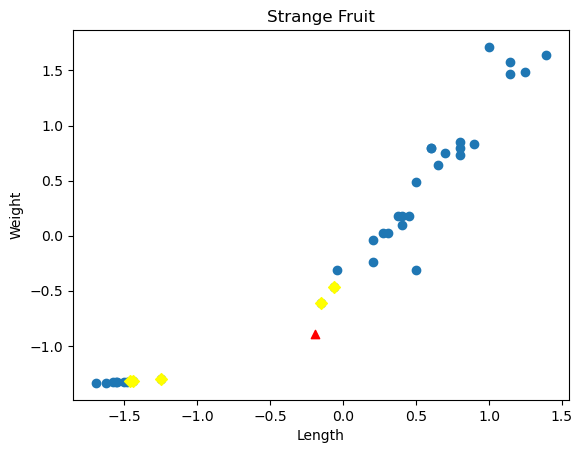

In [43]:
# 이웃의 위치를 추력
distances, indexs = kn.kneighbors([new1])

plt.scatter(
    train_scaled3[:, 0],
    train_scaled3[:, 1]
)

plt.scatter(
    new1[0],
    new1[1],
    marker="^",
    c='red'
)

plt.scatter(
    train_scaled3[indexes, 0],
    train_scaled3[indexes, 1],
    marker='D',
    c='yellow'
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('Strange Fruit')

plt.show()